# Code to generate RDMs for time averaged stimuli for review rebuttal

In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import copy

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
embeddings_path = '/om2/user/imgriff/projects/torch_2_aud_attn/acts_for_RDM_analysis/word_task_v10_main_feature_gain_config/word_task_v10_main_feature_gain_config_model_activations_0dB_time_avg.h5'

embeddings = h5py.File(embeddings_path, 'r')

In [3]:
layer_names = ['norm_coch_rep',
            'attn0',
            'conv_block_0_ln',
            'conv_block_0_relu',
            'hann_pool_0',
            'attn1',
            'conv_block_1_ln',
            'conv_block_1_relu',
            'hann_pool_1',
            'attn2',
            'conv_block_2_ln',
            'conv_block_2_relu',
            'hann_pool_2',
            'attn3',
            'conv_block_3_ln',
            'conv_block_3_relu',
            'hann_pool_3',
            'attn4',
            'conv_block_4_ln',
            'conv_block_4_relu',
            'hann_pool_4',
            'attn5',
            'conv_block_5_ln',
            'conv_block_5_relu',
            'hann_pool_5',
            'attn6',
            'conv_block_6_ln',
            'conv_block_6_relu',
            'hann_pool_6',
            'attnfc',
            'relufc']

signal_names = ['cue', 'target', 'same_sex_sig', 'diff_sex_sig', 'nat_scene_sig', 'mixture_same_sex', 'mixture_diff_sex', 'mixture_nat_scene']

attn_type = ['single_source', 'cued']

In [4]:
target_locs = embeddings['target_loc']
target_f0s = embeddings['target_f0']

In [5]:
single_src_coch_reps = embeddings['norm_coch_rep_target_single_source']
print(single_src_coch_reps.shape)

(1400, 80)


In [6]:
unique_locs = np.unique(target_locs, axis=0)

loc_to_idx = {}
# create map of unique locations to index
for loc in unique_locs:
    rows = np.where(np.all(target_locs == loc, axis=1))[0]
    loc_to_idx[tuple(loc)] = rows

/tmp/ipykernel_973136/3426988523.py:6: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  rows = np.where(np.all(target_locs == loc, axis=1))[0]


In [13]:
def pearson_r(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.shape != Y.shape:
        raise ValueError(f"Shape mismatch: X{X.shape} vs Y{Y.shape}")

    Xc = X - X.mean(axis=1, keepdims=True)
    Yc = Y - Y.mean(axis=1, keepdims=True)

    Xnorm = np.linalg.norm(Xc, axis=1)
    Ynorm = np.linalg.norm(Yc, axis=1)
    denom = Xnorm * Ynorm

    num = np.sum(Xc * Yc, axis=1)

    with np.errstate(invalid='ignore', divide='ignore'):
        r_rows = num / denom
    r_rows[denom == 0] = np.nan

    # average over valid rows
    if np.all(np.isnan(r_rows)):
        return np.nan
    return np.nanmean(r_rows)


def l2_dist(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.shape != Y.shape:
        raise ValueError(f"Shape mismatch: X{X.shape} vs Y{Y.shape}")
    diffs = X - Y                       # (N, D)
    row_norms = np.linalg.norm(diffs, axis=1)  # (N,)
    return float(row_norms.mean())


def plot_lower_triangle(matrix, title, loc_labels, cmap='viridis'):
    mask = ~np.tril(np.ones_like(matrix, dtype=bool), k=0)
    masked = np.ma.masked_array(matrix, mask=mask)
    plt.figure(figsize=(10, 10))
    im = plt.imshow(masked, cmap=cmap, vmin=np.nanmin(masked), vmax=np.nanmax(masked))
    plt.colorbar(im)
    plt.xticks(np.arange(len(loc_labels)), loc_labels, rotation=45, ha='right')
    plt.yticks(np.arange(len(loc_labels)), loc_labels)
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel("Location")
    plt.ylabel("Location")
    plt.tight_layout()
    plt.show()

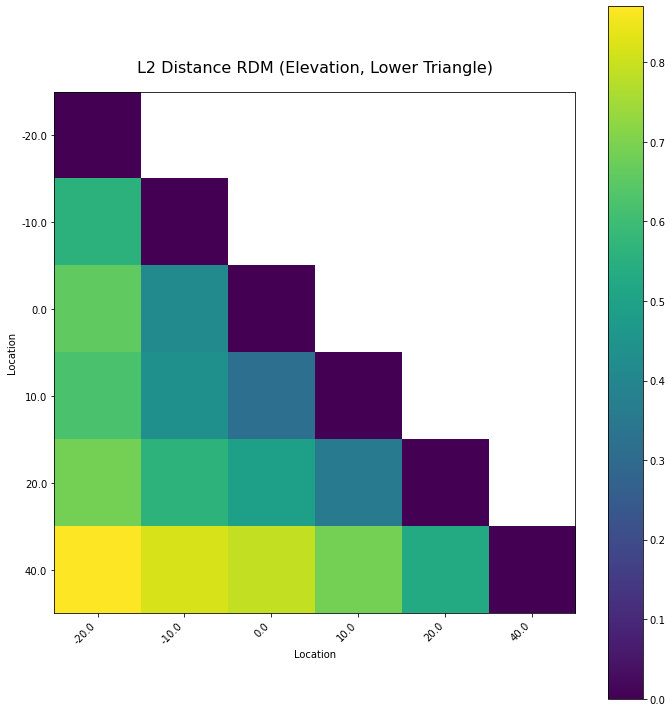

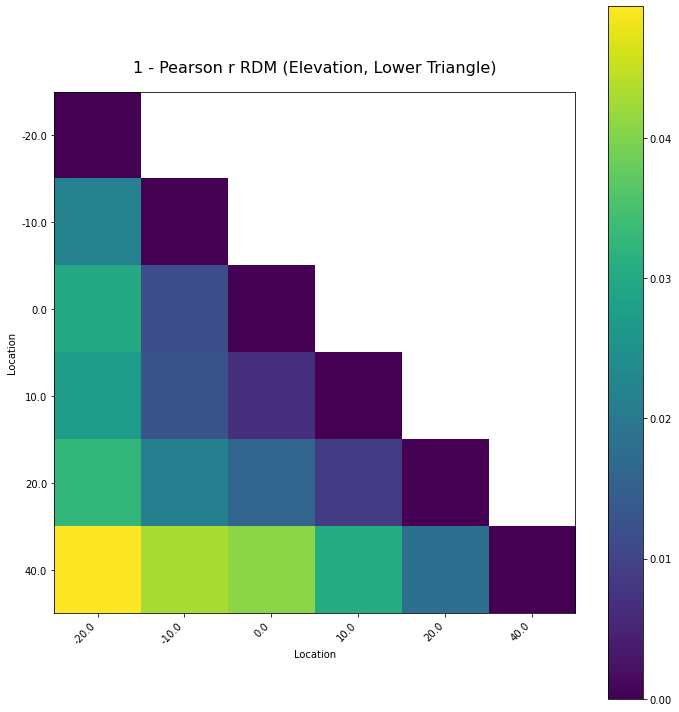

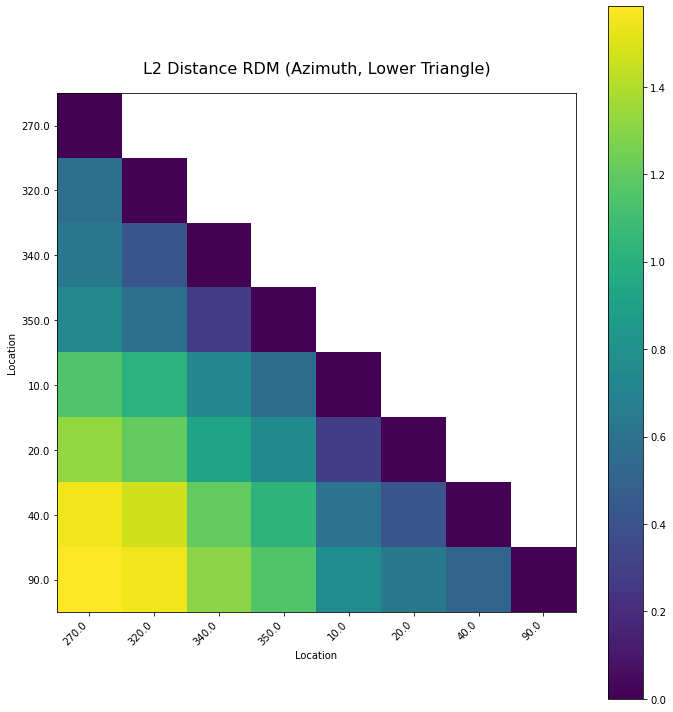

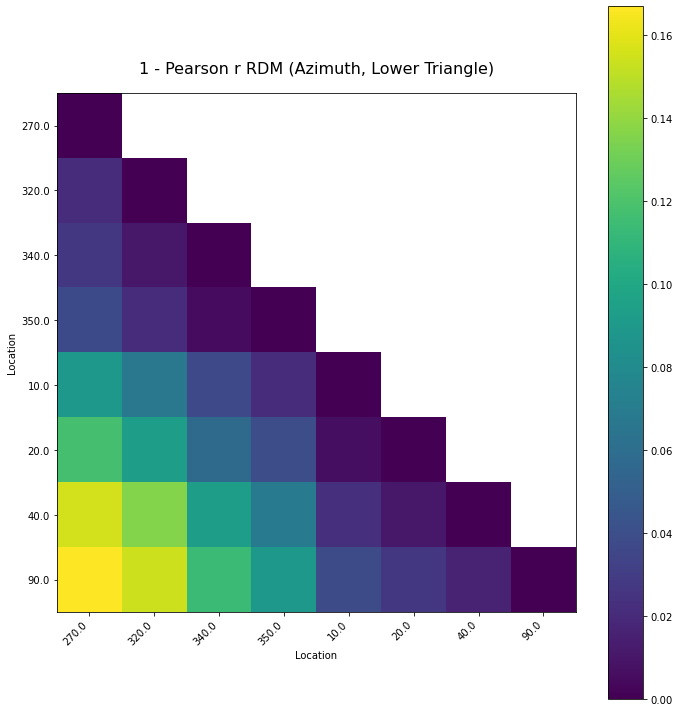

In [17]:
# Plot RDMs for elevation and azimuth locations separately, labeling only the varying dimension

# --- collect locations ---
elev_locs = [
    (0.0, -20.0),
    (0.0, -10.0),
    (0.0, 0.0),
    (0.0, 10.0),
    (0.0, 20.0),
    (0.0, 40.0),
]

azim_locs = [
    (270.0, 0.0),
    (320.0, 0.0),
    (340.0, 0.0),
    (350.0, 0.0),
    (10.0, 0.0),
    (20.0, 0.0),
    (40.0, 0.0),
    (90.0, 0.0),
]

# --- Elevation RDMs (varying elevation, azimuth fixed at 0.0) ---
elev_labels = [f"{elev:.1f}" for (_, elev) in elev_locs]
n_elev = len(elev_locs)
elev_pearson_r_matrix = np.full((n_elev, n_elev), np.nan, dtype=float)
elev_l2_dist_matrix  = np.full((n_elev, n_elev), np.nan, dtype=float)

for i in range(n_elev):
    Xi = single_src_coch_reps[loc_to_idx[elev_locs[i]]]  # (N, D)
    elev_pearson_r_matrix[i, i] = 0.0
    elev_l2_dist_matrix[i, i]   = 0.0
    for j in range(i):
        Xj = single_src_coch_reps[loc_to_idx[elev_locs[j]]]  # (N, D)
        r  = pearson_r(Xi, Xj)
        d  = l2_dist(Xi, Xj)
        elev_pearson_r_matrix[i, j] = elev_pearson_r_matrix[j, i] = 1 - r
        elev_l2_dist_matrix[i, j]   = elev_l2_dist_matrix[j, i]   = d

plot_lower_triangle(
    elev_l2_dist_matrix,
    "L2 Distance RDM (Elevation, Lower Triangle)",
    elev_labels,
    cmap='viridis'
)
plot_lower_triangle(
    elev_pearson_r_matrix,
    "1 - Pearson r RDM (Elevation, Lower Triangle)",
    elev_labels,
    cmap='viridis'
)

# --- Azimuth RDMs (varying azimuth, elevation fixed at 0.0) ---
azim_labels = [f"{azim:.1f}" for (azim, _) in azim_locs]
n_azim = len(azim_locs)
azim_pearson_r_matrix = np.full((n_azim, n_azim), np.nan, dtype=float)
azim_l2_dist_matrix  = np.full((n_azim, n_azim), np.nan, dtype=float)

for i in range(n_azim):
    Xi = single_src_coch_reps[loc_to_idx[azim_locs[i]]]  # (N, D)
    azim_pearson_r_matrix[i, i] = 0.0
    azim_l2_dist_matrix[i, i]   = 0.0
    for j in range(i):
        Xj = single_src_coch_reps[loc_to_idx[azim_locs[j]]]  # (N, D)
        r  = pearson_r(Xi, Xj)
        d  = l2_dist(Xi, Xj)
        azim_pearson_r_matrix[i, j] = azim_pearson_r_matrix[j, i] = 1 - r
        azim_l2_dist_matrix[i, j]   = azim_l2_dist_matrix[j, i]   = d

plot_lower_triangle(
    azim_l2_dist_matrix,
    "L2 Distance RDM (Azimuth, Lower Triangle)",
    azim_labels,
    cmap='viridis'
)
plot_lower_triangle(
    azim_pearson_r_matrix,
    "1 - Pearson r RDM (Azimuth, Lower Triangle)",
    azim_labels,
    cmap='viridis'
)


/tmp/ipykernel_973136/1613163104.py:36: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  target_f0s = np.asarray(target_f0s).reshape(-1)  # ensure 1D


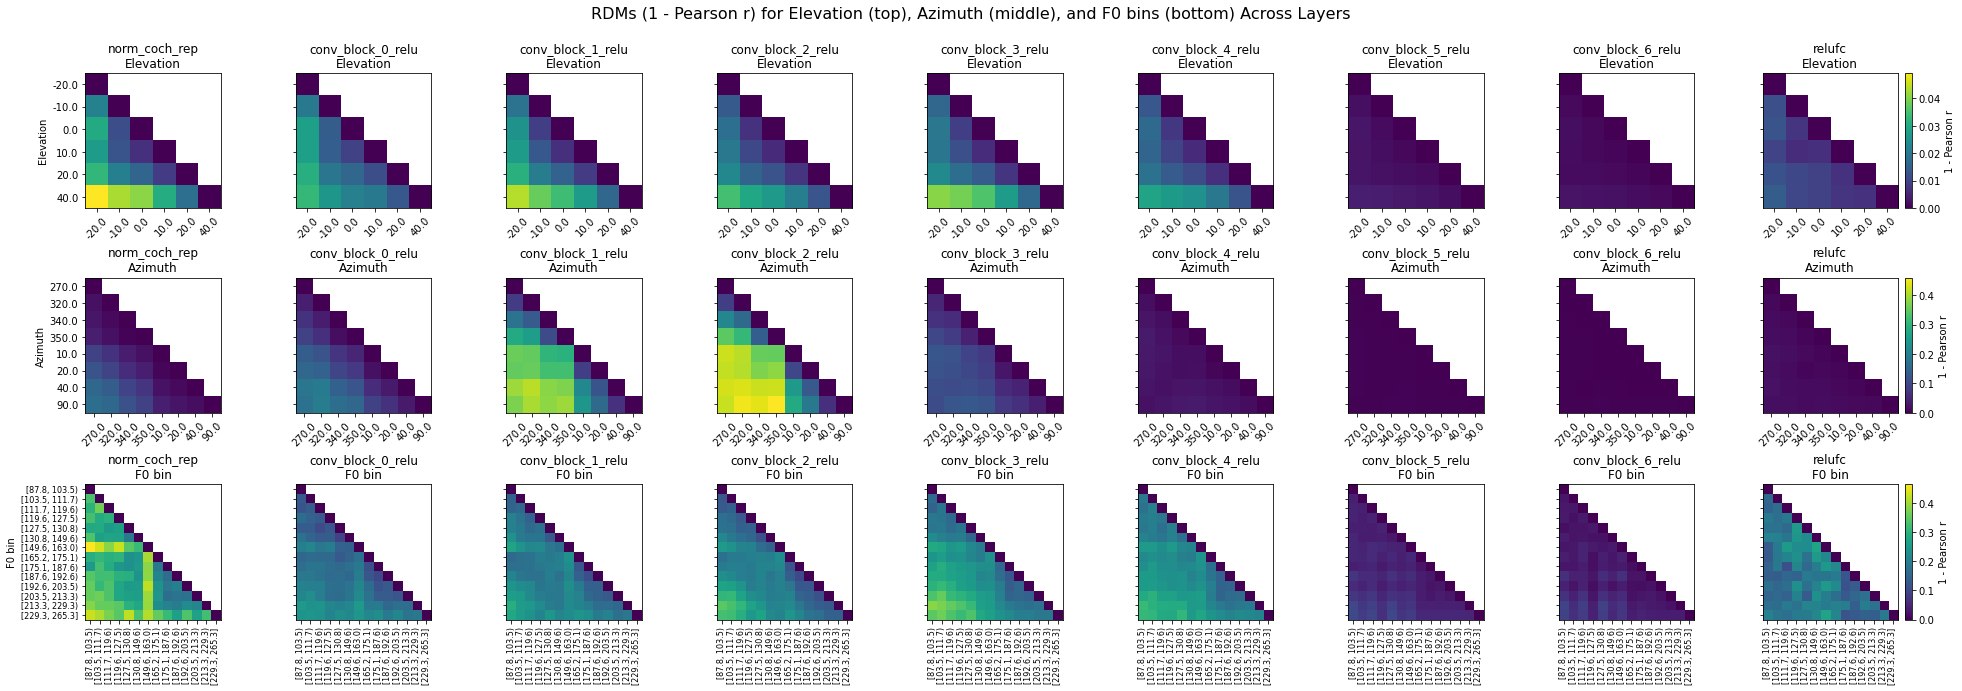

In [32]:
# --- collect locations ---
elev_locs = [
    (0.0, -20.0),
    (0.0, -10.0),
    (0.0, 0.0),
    (0.0, 10.0),
    (0.0, 20.0),
    (0.0, 40.0),
]

azim_locs = [
    (270.0, 0.0),
    (320.0, 0.0),
    (340.0, 0.0),
    (350.0, 0.0),
    (10.0, 0.0),
    (20.0, 0.0),
    (40.0, 0.0),
    (90.0, 0.0),
]

target_f0s = embeddings['target_f0']

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

elev_labels = [f"{elev:.1f}" for (_, elev) in elev_locs]
azim_labels = [f"{azim:.1f}" for (azim, _) in azim_locs]
n_elev = len(elev_locs)
n_azim = len(azim_locs)

# --- F0 binning (14 equal-count quantile bins) ---
n_f0_bins = 14
target_f0s = np.asarray(target_f0s).reshape(-1)  # ensure 1D

N = target_f0s.size
if N < n_f0_bins:
    n_f0_bins = N

order = np.argsort(target_f0s, kind="mergesort")
bin_index_lists = np.array_split(order, n_f0_bins)

f0_bin_indices = np.empty(N, dtype=int)
for b, idxs in enumerate(bin_index_lists):
    f0_bin_indices[idxs] = b

f0_bin_labels = []
for b, idxs in enumerate(bin_index_lists):
    if idxs.size == 0:
        f0_bin_labels.append(f"[empty]")
        continue
    left = float(target_f0s[idxs[0]])
    right = float(target_f0s[idxs[-1]])
    if b == n_f0_bins - 1:
        f0_bin_labels.append(f"[{left:.1f}, {right:.1f}]")
    else:
        f0_bin_labels.append(f"[{left:.1f}, {right:.1f})")

n_f0 = n_f0_bins

# Make 3 x 9 grid (add row for F0 bins)
fig, axes = plt.subplots(3, 9, figsize=(27, 9), constrained_layout=True)

def lower_triangle_only(mat, k=0):
    mask = np.triu(np.ones_like(mat, dtype=bool), k=k)
    mat_masked = mat.copy()
    mat_masked[mask] = np.nan
    return mat_masked

# --- Precompute all RDMs for all layers for each row, so we can get global vmin/vmax per row ---
# Each is a list of matrices, one per layer
elev_rdms = []
azim_rdms = []
f0_rdms = []

for layer in layers_of_interest:
    # Elevation
    elev_pearson_r_matrix = np.full((n_elev, n_elev), np.nan, dtype=float)
    layer_reps = embeddings[f'{layer}_target_single_source']
    for i in range(n_elev):
        Xi = layer_reps[loc_to_idx[elev_locs[i]]]
        elev_pearson_r_matrix[i, i] = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[elev_locs[j]]]
            r = pearson_r(Xi, Xj)
            elev_pearson_r_matrix[i, j] = elev_pearson_r_matrix[j, i] = 1 - r
    elev_lower = lower_triangle_only(elev_pearson_r_matrix, k=1)
    elev_rdms.append(elev_lower)

    # Azimuth
    azim_pearson_r_matrix = np.full((n_azim, n_azim), np.nan, dtype=float)
    for i in range(n_azim):
        Xi = layer_reps[loc_to_idx[azim_locs[i]]]
        azim_pearson_r_matrix[i, i] = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[azim_locs[j]]]
            r = pearson_r(Xi, Xj)
            azim_pearson_r_matrix[i, j] = azim_pearson_r_matrix[j, i] = 1 - r
    azim_lower = lower_triangle_only(azim_pearson_r_matrix, k=1)
    azim_rdms.append(azim_lower)

    # F0 bins
    f0_pearson_r_matrix = np.full((n_f0_bins, n_f0_bins), np.nan, dtype=float)
    per_bin_reps = []
    for bin_idx in range(n_f0_bins):
        idxs = np.where(f0_bin_indices == bin_idx)[0]
        if idxs.size == 0:
            per_bin_reps.append(np.full_like(layer_reps[0:1], np.nan))
        else:
            per_bin_reps.append(layer_reps[idxs])
    for i in range(n_f0_bins):
        Xi = per_bin_reps[i]
        f0_pearson_r_matrix[i, i] = 0.0
        for j in range(i):
            Xj = per_bin_reps[j]
            if np.isnan(Xi).all() or np.isnan(Xj).all():
                continue
            r = pearson_r(Xi, Xj)
            f0_pearson_r_matrix[i, j] = f0_pearson_r_matrix[j, i] = 1 - r
    f0_lower = lower_triangle_only(f0_pearson_r_matrix, k=1)
    f0_rdms.append(f0_lower)

# Compute vmin/vmax for each row across all layers
elev_vmin = np.nanmin([np.nanmin(rdm) for rdm in elev_rdms])
elev_vmax = np.nanmax([np.nanmax(rdm) for rdm in elev_rdms])
azim_vmin = np.nanmin([np.nanmin(rdm) for rdm in azim_rdms])
azim_vmax = np.nanmax([np.nanmax(rdm) for rdm in azim_rdms])
f0_vmin   = np.nanmin([np.nanmin(rdm) for rdm in f0_rdms])
f0_vmax   = np.nanmax([np.nanmax(rdm) for rdm in f0_rdms])

# Store the image handles for each row for colorbars
elev_ims = []
azim_ims = []
f0_ims = []

for col, layer in enumerate(layers_of_interest):
    # --- Elevation RDMs (top row) ---
    ax = axes[0, col]
    elev_lower = elev_rdms[col]
    im = ax.imshow(elev_lower, cmap='viridis', vmin=elev_vmin, vmax=elev_vmax)
    elev_ims.append(im)
    ax.set_title(f"{layer}\nElevation")
    ax.set_xticks(range(n_elev))
    ax.set_yticks(range(n_elev))
    ax.set_xticklabels(elev_labels, rotation=45)
    if col == 0:
        ax.set_yticklabels(elev_labels)
        ax.set_ylabel("Elevation")
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # --- Azimuth RDMs (middle row) ---
    ax = axes[1, col]
    azim_lower = azim_rdms[col]
    im = ax.imshow(azim_lower, cmap='viridis', vmin=azim_vmin, vmax=azim_vmax)
    azim_ims.append(im)
    ax.set_title(f"{layer}\nAzimuth")
    ax.set_xticks(range(n_azim))
    ax.set_yticks(range(n_azim))
    ax.set_xticklabels(azim_labels, rotation=45)
    if col == 0:
        ax.set_yticklabels(azim_labels)
        ax.set_ylabel("Azimuth")
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # --- F0 bin RDMs (bottom row) ---
    ax = axes[2, col]
    f0_lower = f0_rdms[col]
    im = ax.imshow(f0_lower, cmap='viridis', vmin=f0_vmin, vmax=f0_vmax)
    f0_ims.append(im)
    ax.set_title(f"{layer}\nF0 bin")
    ax.set_xticks(range(n_f0_bins))
    ax.set_yticks(range(n_f0_bins))
    ax.set_xticklabels(f0_bin_labels, rotation=90, fontsize=8)
    if col == 0:
        ax.set_yticklabels(f0_bin_labels, fontsize=8)
        ax.set_ylabel("F0 bin")
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

# Add a single colorbar for each row at the far right
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Elevation (top row)
divider = make_axes_locatable(axes[0, -1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(elev_ims[-1], cax=cax)
cbar.set_label("1 - Pearson r")

# Azimuth (middle row)
divider = make_axes_locatable(axes[1, -1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(azim_ims[-1], cax=cax)
cbar.set_label("1 - Pearson r")

# F0 bin (bottom row)
divider = make_axes_locatable(axes[2, -1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(f0_ims[-1], cax=cax)
cbar.set_label("1 - Pearson r")

plt.suptitle("RDMs (1 - Pearson r) for Elevation (top), Azimuth (middle), and F0 bins (bottom) Across Layers", fontsize=16, y=1.05)
plt.show()


/tmp/ipykernel_973136/99597736.py:36: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  target_f0s = np.asarray(target_f0s).reshape(-1)  # ensure 1D


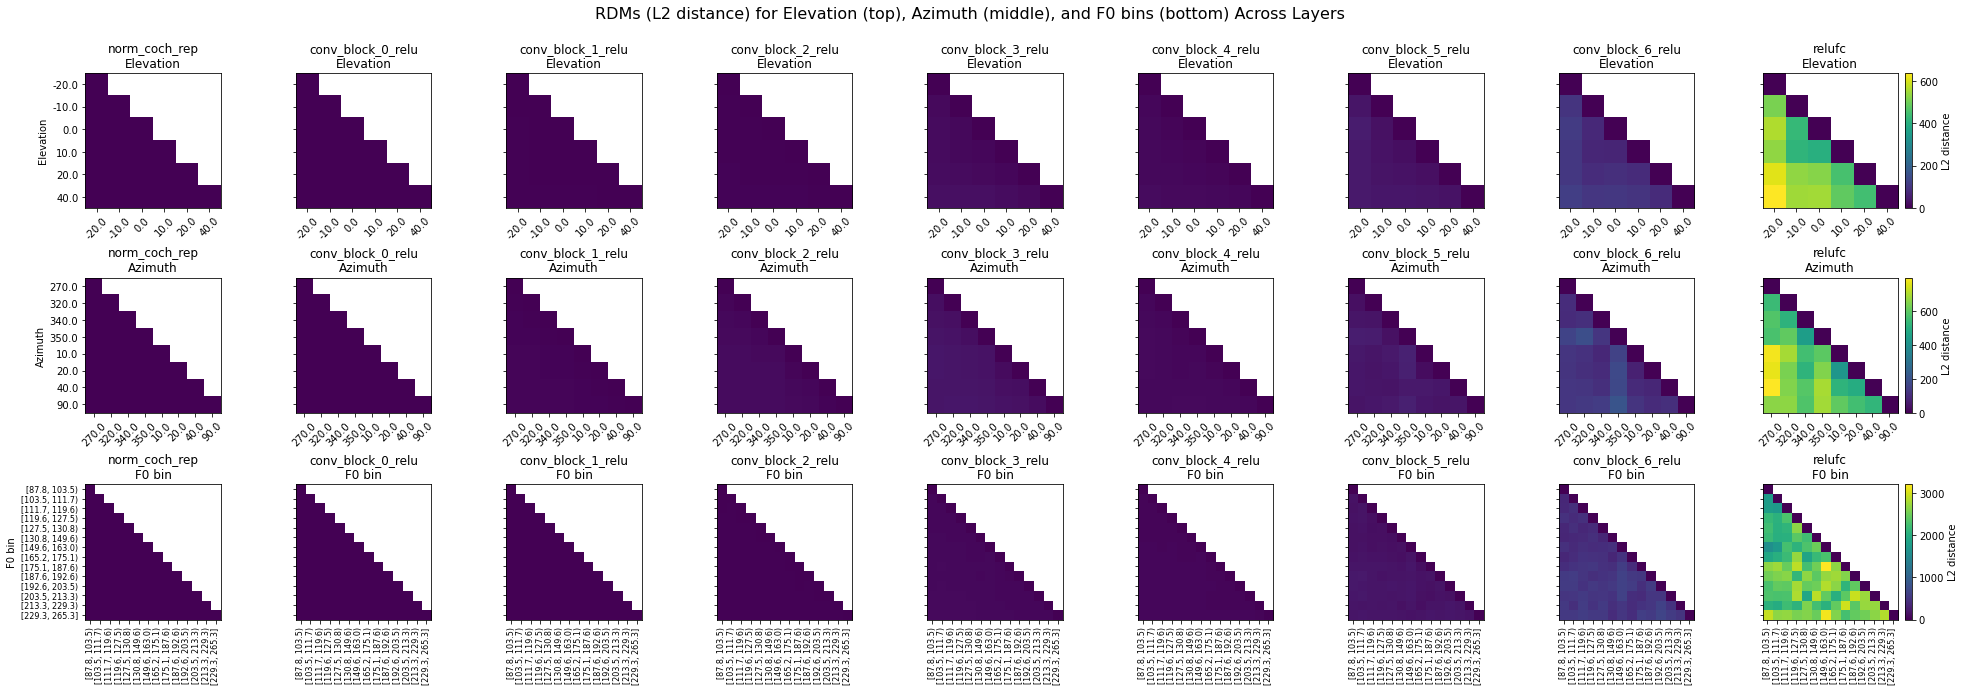

In [33]:
# --- collect locations ---
elev_locs = [
    (0.0, -20.0),
    (0.0, -10.0),
    (0.0, 0.0),
    (0.0, 10.0),
    (0.0, 20.0),
    (0.0, 40.0),
]

azim_locs = [
    (270.0, 0.0),
    (320.0, 0.0),
    (340.0, 0.0),
    (350.0, 0.0),
    (10.0, 0.0),
    (20.0, 0.0),
    (40.0, 0.0),
    (90.0, 0.0),
]

target_f0s = embeddings['target_f0']

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

elev_labels = [f"{elev:.1f}" for (_, elev) in elev_locs]
azim_labels = [f"{azim:.1f}" for (azim, _) in azim_locs]
n_elev = len(elev_locs)
n_azim = len(azim_locs)

# --- F0 binning (14 equal-count quantile bins) ---
n_f0_bins = 14
target_f0s = np.asarray(target_f0s).reshape(-1)  # ensure 1D

N = target_f0s.size
if N < n_f0_bins:
    n_f0_bins = N

order = np.argsort(target_f0s, kind="mergesort")
bin_index_lists = np.array_split(order, n_f0_bins)

f0_bin_indices = np.empty(N, dtype=int)
for b, idxs in enumerate(bin_index_lists):
    f0_bin_indices[idxs] = b

f0_bin_labels = []
for b, idxs in enumerate(bin_index_lists):
    if idxs.size == 0:
        f0_bin_labels.append(f"[empty]")
        continue
    left = float(target_f0s[idxs[0]])
    right = float(target_f0s[idxs[-1]])
    if b == n_f0_bins - 1:
        f0_bin_labels.append(f"[{left:.1f}, {right:.1f}]")
    else:
        f0_bin_labels.append(f"[{left:.1f}, {right:.1f})")

n_f0 = n_f0_bins

# Make 3 x 9 grid (add row for F0 bins)
fig, axes = plt.subplots(3, 9, figsize=(27, 9), constrained_layout=True)

def lower_triangle_only(mat, k=0):
    mask = np.triu(np.ones_like(mat, dtype=bool), k=k)
    mat_masked = mat.copy()
    mat_masked[mask] = np.nan
    return mat_masked

# --- Precompute all RDMs for all layers for each row, so we can get global vmin/vmax per row ---
# Each is a list of matrices, one per layer
elev_rdms = []
azim_rdms = []
f0_rdms = []

for layer in layers_of_interest:
    # Elevation
    elev_l2_matrix = np.full((n_elev, n_elev), np.nan, dtype=float)
    layer_reps = embeddings[f'{layer}_target_single_source']
    for i in range(n_elev):
        Xi = layer_reps[loc_to_idx[elev_locs[i]]]
        elev_l2_matrix[i, i] = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[elev_locs[j]]]
            d = l2_dist(Xi, Xj)
            elev_l2_matrix[i, j] = elev_l2_matrix[j, i] = d
    elev_lower = lower_triangle_only(elev_l2_matrix, k=1)
    elev_rdms.append(elev_lower)

    # Azimuth
    azim_l2_matrix = np.full((n_azim, n_azim), np.nan, dtype=float)
    for i in range(n_azim):
        Xi = layer_reps[loc_to_idx[azim_locs[i]]]
        azim_l2_matrix[i, i] = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[azim_locs[j]]]
            d = l2_dist(Xi, Xj)
            azim_l2_matrix[i, j] = azim_l2_matrix[j, i] = d
    azim_lower = lower_triangle_only(azim_l2_matrix, k=1)
    azim_rdms.append(azim_lower)

    # F0 bins
    f0_l2_matrix = np.full((n_f0_bins, n_f0_bins), np.nan, dtype=float)
    per_bin_reps = []
    for bin_idx in range(n_f0_bins):
        idxs = np.where(f0_bin_indices == bin_idx)[0]
        if idxs.size == 0:
            per_bin_reps.append(np.full_like(layer_reps[0:1], np.nan))
        else:
            per_bin_reps.append(layer_reps[idxs])
    for i in range(n_f0_bins):
        Xi = per_bin_reps[i]
        f0_l2_matrix[i, i] = 0.0
        for j in range(i):
            Xj = per_bin_reps[j]
            if np.isnan(Xi).all() or np.isnan(Xj).all():
                continue
            d = l2_dist(Xi, Xj)
            f0_l2_matrix[i, j] = f0_l2_matrix[j, i] = d
    f0_lower = lower_triangle_only(f0_l2_matrix, k=1)
    f0_rdms.append(f0_lower)

# Compute vmin/vmax for each row across all layers
elev_vmin = np.nanmin([np.nanmin(rdm) for rdm in elev_rdms])
elev_vmax = np.nanmax([np.nanmax(rdm) for rdm in elev_rdms])
azim_vmin = np.nanmin([np.nanmin(rdm) for rdm in azim_rdms])
azim_vmax = np.nanmax([np.nanmax(rdm) for rdm in azim_rdms])
f0_vmin   = np.nanmin([np.nanmin(rdm) for rdm in f0_rdms])
f0_vmax   = np.nanmax([np.nanmax(rdm) for rdm in f0_rdms])

# Store the image handles for each row for colorbars
elev_ims = []
azim_ims = []
f0_ims = []

for col, layer in enumerate(layers_of_interest):
    # --- Elevation RDMs (top row) ---
    ax = axes[0, col]
    elev_lower = elev_rdms[col]
    im = ax.imshow(elev_lower, cmap='viridis', vmin=elev_vmin, vmax=elev_vmax)
    elev_ims.append(im)
    ax.set_title(f"{layer}\nElevation")
    ax.set_xticks(range(n_elev))
    ax.set_yticks(range(n_elev))
    ax.set_xticklabels(elev_labels, rotation=45)
    if col == 0:
        ax.set_yticklabels(elev_labels)
        ax.set_ylabel("Elevation")
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # --- Azimuth RDMs (middle row) ---
    ax = axes[1, col]
    azim_lower = azim_rdms[col]
    im = ax.imshow(azim_lower, cmap='viridis', vmin=azim_vmin, vmax=azim_vmax)
    azim_ims.append(im)
    ax.set_title(f"{layer}\nAzimuth")
    ax.set_xticks(range(n_azim))
    ax.set_yticks(range(n_azim))
    ax.set_xticklabels(azim_labels, rotation=45)
    if col == 0:
        ax.set_yticklabels(azim_labels)
        ax.set_ylabel("Azimuth")
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # --- F0 bin RDMs (bottom row) ---
    ax = axes[2, col]
    f0_lower = f0_rdms[col]
    im = ax.imshow(f0_lower, cmap='viridis', vmin=f0_vmin, vmax=f0_vmax)
    f0_ims.append(im)
    ax.set_title(f"{layer}\nF0 bin")
    ax.set_xticks(range(n_f0_bins))
    ax.set_yticks(range(n_f0_bins))
    ax.set_xticklabels(f0_bin_labels, rotation=90, fontsize=8)
    if col == 0:
        ax.set_yticklabels(f0_bin_labels, fontsize=8)
        ax.set_ylabel("F0 bin")
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

# Add a single colorbar for each row at the far right
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Elevation (top row)
divider = make_axes_locatable(axes[0, -1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(elev_ims[-1], cax=cax)
cbar.set_label("L2 distance")

# Azimuth (middle row)
divider = make_axes_locatable(axes[1, -1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(azim_ims[-1], cax=cax)
cbar.set_label("L2 distance")

# F0 bin (bottom row)
divider = make_axes_locatable(axes[2, -1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(f0_ims[-1], cax=cax)
cbar.set_label("L2 distance")

plt.suptitle("RDMs (L2 distance) for Elevation (top), Azimuth (middle), and F0 bins (bottom) Across Layers", fontsize=16, y=1.05)
plt.show()
